¡Hola, Aron!

Mi nombre es Tonatiuh Cruz. Me complace revisar tu proyecto hoy.

Al identificar cualquier error inicialmente, simplemente los destacaré. Te animo a localizar y abordar los problemas de forma independiente como parte de tu preparación para un rol como data-analyst. En un entorno profesional, tu líder de equipo seguiría un enfoque similar. Si encuentras la tarea desafiante, proporcionaré una pista más específica en la próxima iteración.

Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o elimines**.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Éxito. Todo está hecho correctamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con comentarios en rojo.
</div>

Puedes responderme utilizando esto:


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-success">
<b>Resumen de la revisión 1</b> <a class="tocSkip"></a>

Hola Aron! Has hecho un excelente trabajo al realizar con el desarrollo del proyecto, realizas un tratamiento inicial a los datos, el filtro de estos y las pruebas indicadas. Solamente te dejo algunos comentarios para terminar de complementar el análisis

Sigue con el excelente trabajo!
</div>

# Proyecto de pruebas A/B

## Ejercicio

Cargar Librerias

In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

Cargar datas

In [2]:
participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
new_users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
marketing = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')


<div class="alert alert-block alert-success">
<b>Comentario del revisor:</b> <a class="tocSkip"></a>
    
Has realizado un excelente trabajo al importar los datos y las bibliotecas necesarias.

</div>

In [3]:
participants.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


In [4]:
events.head()

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


In [5]:
new_users.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [6]:
marketing.head()

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


## ¿Es necesario convertir los tipos? si Convertir datos a datatime

In [7]:
events["event_dt"]   = pd.to_datetime(events["event_dt"], errors="coerce")
new_users["first_date"] = pd.to_datetime(new_users["first_date"], errors="coerce")
marketing["start_dt"]   = pd.to_datetime(marketing["start_dt"], errors="coerce")
marketing["finish_dt"]  = pd.to_datetime(marketing["finish_dt"], errors="coerce")

<div class="alert alert-block alert-success">
    <b>Comentario del revisor:</b> <a class="tocSkip"></a>
    
Aron, muy buen trabajo con la conversión de los tipos de datos, así como la extracción de la fecha y hora

Además, más adelante eliminar registros duplicados es esencial en el análisis de datos para evitar que sesguen nuestros resultados.
</div>

## ¿Hay valores ausentes o duplicados? Si es así, ¿cómo los caracterizarías?

In [8]:
print(events.isna().sum())

user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64


los data frames se muestran limpios pero el dataframe de eventos da la el resultado de que hay ausentes pero parece que es por la forma del llenado de los datos

In [9]:
if "details" in events.columns:
    events["details_num"] = pd.to_numeric(events["details"], errors="coerce")


In [10]:
events.dtypes

user_id                object
event_dt       datetime64[ns]
event_name             object
details               float64
details_num           float64
dtype: object

## Estudia la conversión en las diferentes etapas del embudo.

Parametros de experimento

In [11]:
TEST_NAME   = "recommender_system_test"
LAUNCH      = pd.Timestamp("2020-12-07")
STOP_INTAKE = pd.Timestamp("2020-12-21")
FINAL_DATE  = pd.Timestamp("2021-01-01")
WINDOW_DAYS = 14
FUNNEL      = ["product_page", "product_cart", "purchase"]

In [12]:
new_users_eu = new_users.loc[new_users["region"] == "EU"].copy()
intake_eu = new_users_eu.loc[
    (new_users_eu["first_date"] >= LAUNCH) & (new_users_eu["first_date"] <= STOP_INTAKE)
].copy()

In [13]:
participants_test = participants.loc[participants["ab_test"] == TEST_NAME].copy()
enrolled = participants_test.merge(
    intake_eu[["user_id","first_date","device","region"]],
    on="user_id", how="inner"
).rename(columns={"first_date":"enroll_date"})

In [14]:
enrolled["window_end"] = (enrolled["enroll_date"] + pd.to_timedelta(WINDOW_DAYS, unit="D")).clip(upper=FINAL_DATE)


Limitar eventos a la venta de usuarios

In [15]:
evt = events.merge(enrolled[["user_id","group","enroll_date","window_end"]], on="user_id", how="inner")
evt = evt[(evt["event_dt"] >= evt["enroll_date"]) & (evt["event_dt"] <= evt["window_end"])]


<div class="alert alert-block alert-success">
    <b>Comentario del revisor:</b> <a class="tocSkip"></a>
    
Aron, excelente trabajo,   antes de proceder con el análisi realizas los siguientes filtros que nos mencionan en el proyecto:
    
    - Agregar un filtro de los eventos de marketing aplicables a la region "UE", dado que con base en el ejercicio son los eventos de análisis.
    - verificar que las fechas de aplicación corresponden con lo que indica el ejercicio (fechas entre 2020-12-07 y 2021-01-01)
    - Filtrar los eventos relevante para el análisis
    - Verificar que consideramos los primeros 14 días desde que se registraron los usuarios
</div>

eventos en el tunel

In [16]:
evt_funnel = evt[evt["event_name"].isin(FUNNEL)].copy()

In [17]:
user_flags = (
    evt_funnel
    .pivot_table(index=["user_id","group"], columns="event_name", values="event_dt", aggfunc="min")
    .reset_index()
)

In [18]:
for step in FUNNEL:
    if step not in user_flags.columns:
        user_flags[step] = pd.NaT
    user_flags[f"has_{step}"] = ~user_flags[step].isna()


Poblacion/ usuarios sin eventos

In [19]:
full = enrolled.merge(
    user_flags[["user_id","group"] + [f"has_{s}" for s in FUNNEL]],
    on=["user_id","group"], how="left"
)
for step in FUNNEL:
    full[f"has_{step}"] = full[f"has_{step}"].fillna(False)


conversion global 

In [20]:
summary_all = pd.DataFrame({
    "Stage": FUNNEL,
    "Users_reached": [full[f"has_{s}"].sum() for s in FUNNEL],
    "Conversion_rate (%)": [round(full[f"has_{s}"].mean()*100, 2) for s in FUNNEL],
}).set_index("Stage")

In [21]:
pp_total = full["has_product_page"].sum()
pc_total = full["has_product_cart"].sum()
pp_to_cart = round(full.loc[full["has_product_page"], "has_product_cart"].mean()*100, 2) if pp_total>0 else np.nan
cart_to_purchase = round(full.loc[full["has_product_cart"], "has_purchase"].mean()*100, 2) if pc_total>0 else np.nan

In [22]:
conditional_all = pd.DataFrame({
    "Transition": ["product_page → product_cart", "product_cart → purchase"],
    "Conversion_rate (%)": [pp_to_cart, cart_to_purchase]
})

In [23]:

def summarize_group(df):
    res = {
        "n_users": df["user_id"].nunique(),
        "cr_product_page (%)": round(df["has_product_page"].mean()*100, 2),
        "cr_product_cart (%)": round(df["has_product_cart"].mean()*100, 2),
        "cr_purchase (%)": round(df["has_purchase"].mean()*100, 2),
    }
    
    pp = df["has_product_page"].sum()
    pc = df["has_product_cart"].sum()
    res["pp→cart (%)"] = round(df.loc[df["has_product_page"], "has_product_cart"].mean()*100, 2) if pp>0 else np.nan
    res["cart→purchase (%)"] = round(df.loc[df["has_product_cart"], "has_purchase"].mean()*100, 2) if pc>0 else np.nan
    return pd.Series(res)

In [24]:
by_group = full.groupby("group").apply(summarize_group).reset_index()

In [25]:

print("\nEDA — Funnel (EU, 14 días) — Conversión global")
print(summary_all)
print("\nEDA — Funnel (EU, 14 días) — Conversión condicional global")
print(conditional_all)
print("\nEDA — Funnel (EU, 14 días) — Conversión por grupo")
print(by_group)



EDA — Funnel (EU, 14 días) — Conversión global
              Users_reached  Conversion_rate (%)
Stage                                           
product_page           2178                62.57
product_cart           1026                29.47
purchase               1082                31.08

EDA — Funnel (EU, 14 días) — Conversión condicional global
                    Transition  Conversion_rate (%)
0  product_page → product_cart                29.66
1      product_cart → purchase                32.75

EDA — Funnel (EU, 14 días) — Conversión por grupo
  group  n_users  cr_product_page (%)  cr_product_cart (%)  cr_purchase (%)  \
0     A   2604.0                64.71                30.03            31.99   
1     B    877.0                56.21                27.82            28.39   

   pp→cart (%)  cart→purchase (%)  
0        30.27              33.38  
1        27.59              30.74  


Grafico global

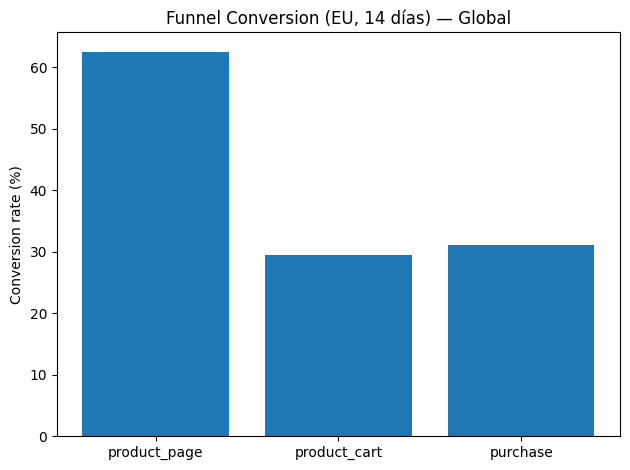

In [26]:

plt.figure()
plt.bar(summary_all.index, summary_all["Conversion_rate (%)"])
plt.title("Funnel Conversion (EU, 14 días) — Global")
plt.ylabel("Conversion rate (%)")
plt.tight_layout()
plt.show()


grafico por grupo

<Figure size 640x480 with 0 Axes>

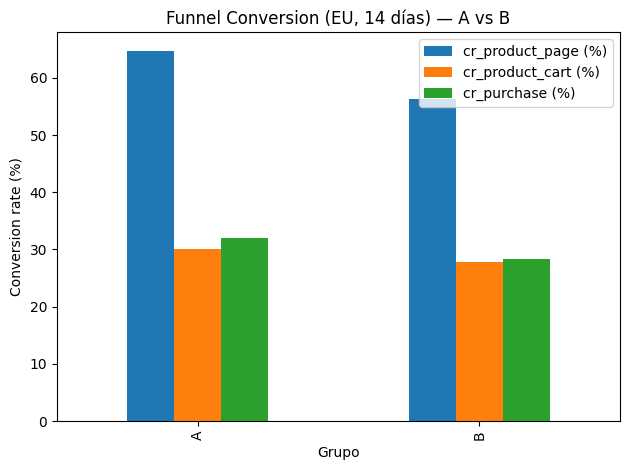

In [27]:

plt.figure()
cols = ["cr_product_page (%)","cr_product_cart (%)","cr_purchase (%)"]
by_group_plot = by_group.set_index("group")[cols]
by_group_plot.plot(kind="bar")
plt.title("Funnel Conversion (EU, 14 días) — A vs B")
plt.ylabel("Conversion rate (%)")
plt.xlabel("Grupo")
plt.tight_layout()
plt.show()


# Observaciones

los graficos muestran que el grupo A tiene algo de ventaja en ciertos eventos como product page o cart purchase. esto puede indicar que el grupo b no a recibido la suficiente incentivo o curiosidad para comprar o interesarse en los productos pero de igual manera haber un crecimiento pequeño pero constante.
EL TEST PARECE CUMPLIR EL OBJETIVO

## ¿El número de eventos por usuario está distribuido equitativamente entre las muestras?

No, desde las graficas anteriores se nota que el grupo A tiene mayor cantidad de usuaruosy eventos realizados en dicho grupo

## ¿Hay usuarios que están presentes en ambas muestras?

In [28]:
p = participants[participants["ab_test"] == TEST_NAME].copy()


In [29]:
dup_global = (
    p.groupby("user_id")["group"]
     .nunique()
     .reset_index(name="distinct_groups")
)
in_both_global = dup_global[dup_global["distinct_groups"] > 1]

In [30]:
print(in_both_global)

Empty DataFrame
Columns: [user_id, distinct_groups]
Index: []


No. No hay usuarios presentes en ambas muestras (A y B).

## ¿Cómo se distribuye el número de eventos entre los días?

In [31]:
evt["event_date"] = evt["event_dt"].dt.date


In [32]:
daily_by_group = (
    evt.groupby(["event_date", "group"])
       .size()                      
       .unstack(fill_value=0)       
       .reset_index()               
)

In [33]:
print(daily_by_group.head())

group  event_date    A    B
0      2020-12-07  318  356
1      2020-12-08  313  238
2      2020-12-09  371  338
3      2020-12-10  331  249
4      2020-12-11  356  161


como dije anteriormente parece haber una ventaja en el grupo A pero el grupo B tambien tiene un crecimiento en los eventos diarios

## ¿Hay alguna peculiaridad en los datos que hay que tener en cuenta antes de iniciar la prueba A/B?

como dije antes me parece que el grupo A estuviera mas atencion de parte del marketing ya que ambos grupos crecen pero el grupo A tiene ventaja en sectores que tendrian influencia por el markting seria bueno checar el marketing dirigido al grupo B

## ¿Qué puedes decir sobre los resultados de la prueba A/B?

mi opnion seria que el grupo b deberia ser retocada su estrategia antes de aplicarse o utilizarse ya que como eh dicho anteriormente parecen haber detalles que no le permite crecer de la mejor manera comparado con el Grupo A. aun cuando los resultados no son tan significativamente distintos es suficiente como para tener que revisarlo. podria haber otros errores que no sean de marketing y de otras cosas en el tramo final o en las paginas claves del grupo B.

## Utiliza una prueba z para comprobar la diferencia estadística entre las proporciones.

In [34]:
def ztest_AB(df, step):
    
    g = (df.groupby("group")[f"has_{step}"]
           .agg(succ="sum", n="size")
           .reindex(["A","B"]))  # asegura orden A,B

    
    if g.isna().any().any() or (g["n"] <= 0).any():
        return pd.Series({"metric": step, "pA": np.nan, "pB": np.nan, "diff": np.nan,
                          "lift": np.nan, "ci_low": np.nan, "ci_high": np.nan,
                          "p_value": np.nan, "nA": np.nan, "succA": np.nan,
                          "nB": np.nan, "succB": np.nan})

    count = g["succ"].to_numpy()   # [succ_A, succ_B]
    nobs  = g["n"].to_numpy()      # [n_A, n_B]

    
    _, pval = proportions_ztest(count, nobs, alternative="two-sided")

    pA, pB = count / nobs
    diff   = pB - pA
    se     = np.sqrt(pA*(1-pA)/nobs[0] + pB*(1-pB)/nobs[1])
    ci_low, ci_high = diff - 1.96*se, diff + 1.96*se
    lift   = (pB/pA - 1) if pA > 0 else np.nan

    return pd.Series({
        "metric": step,
        "pA": float(pA), "pB": float(pB),
        "diff": float(diff),           
        "lift": float(lift),           
        "ci_low": float(ci_low), "ci_high": float(ci_high),
        "p_value": float(pval),
        "nA": int(nobs[0]), "succA": int(count[0]),
        "nB": int(nobs[1]), "succB": int(count[1]),
    })

In [35]:
FUNNEL = ["product_page", "product_cart", "purchase"]

results = pd.DataFrame([ztest_AB(full, step) for step in FUNNEL])

def pct(x): return np.round(100*np.asarray(x), 2)  # a porcentaje / puntos

results_fmt = pd.DataFrame({
    "Métrica":              results["metric"],
    "A (%)":                pct(results["pA"]),
    "B (%)":                pct(results["pB"]),
    "B - A (pp)":           pct(results["diff"]),        # puntos porcentuales
    "Lift rel. B/A (%)":    pct(results["lift"]),
    "CI95% low (pp)":       pct(results["ci_low"]),
    "CI95% high (pp)":      pct(results["ci_high"]),
    "p_value":              np.round(results["p_value"], 4),
    "nA":                   results["nA"],
    "succA":                results["succA"],
    "nB":                   results["nB"],
    "succB":                results["succB"],
})

print(results_fmt.to_string(index=False))

     Métrica  A (%)  B (%)  B - A (pp)  Lift rel. B/A (%)  CI95% low (pp)  CI95% high (pp)  p_value   nA  succA  nB  succB
product_page  64.71  56.21       -8.49             -13.13          -12.26            -4.73   0.0000 2604   1685 877    493
product_cart  30.03  27.82       -2.21              -7.35           -5.66             1.24   0.2147 2604    782 877    244
    purchase  31.99  28.39       -3.60             -11.24           -7.08            -0.12   0.0465 2604    833 877    249


el intervalo de confianza hay bastante diferencia. me parece que los datos arrojan que como deciamos anteriormente el test aun no esta listo para aplicarse almenos al grupo B donde aqui ya se nota aun mas la diferencia contra el grupo A


<div class="alert alert-block alert-warning">
<b>Comentario Revisor</b> <a class="tocSkip"></a>

Muy buen trabajo con el calculo de la z-score y con el desarrollo de la prueba de hipótesis. Solamente te recomendaría agregar una interpretación al z-score obtenido y al resultado del valor p de la prueba de hipótesis.



## Describe tus conclusiones con respecto a la etapa EDA y los resultados de la prueba A/B.

SIgo confirmando entre mas pase de los test el grupo B no esta listo para aplicarse o usarse tiene muchos detalles que mejorar como marketing, paginas, o algunas otras cosas.en la parte del EDA se tuvieron que hacer algunas conversiones de date o tipo habia algunos datos nulos pero se eran por el proceso final de la venta y convertimos details. a float que no lo estaba. quzias seria bueno segmentar un poco mas al grupo B o A por algun dispositivo si se esta usando PC o Celuar o movil por que digo esto por que si el grupo b tuviera muchos integrantes por ejemplo ''pc''  esto podria indicar que puede haber un error en la aplicacion en pc. lo cual seria un error mas tecnico que de proceso.